# Exploring Financial Data using Nasdaq API

In this project, we are going to perform a detailed analysis of financial data from the Nasdaq API. 

The **Nasdaq Data Link API** provides a gateway to a wide range of financial data sets, including comprehensive metrics on various companies. We will focus on the **MER/F1** datatable, which contains detailed financial information such as balance sheets, cash flow statements, and income statements.

We will extract financial data for a specific set of companies, with an emphasis on understanding their financial performance over time. We'll be looking at metrics like Accrued Expenses Turnover and exploring how these values differ among companies and regions.

**Our goal:** To perform a detailed analysis of this financial data, including trend analysis and comparative studies, We will utilize Python for data retrieval, cleaning, and analysis, and create visualizations to present our findings effectively.



In [3]:
#import necessary libraries

import requests
import json
import pandas as pd
import config

# using config, import your api key
api_key = config.API_KEY

In [4]:
# base url
api_url = 'https://data.nasdaq.com/api/v3/datatables/MER/F1.json?'

# parameters dictionary
parameters = {
    'api_key':api_key,
    'qopts.per_page': 10,
}

# perform a practice get() request
response = requests.get(api_url, params=parameters)
json_data = response.json()

In [5]:
print(json_data)

{'datatable': {'data': [[2438, 1868192544, -1802, 10.481948, '2011-06-30', 'Q2', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60325', '(49) 69 910 00', '(49) 69 910 34 225', 'www.db.com', '2023-12-31', 'Accrued Expenses Turnover', 'Derived'], [2438, 1868216112, -1802, 8.161754, '2011-09-30', 'Q3', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60325', '(49) 69 910 00', '(49) 69 910 34 225', 'www.db.com', '2023-12-31', 'Accrued Expenses Turnover', 'Derived'], [2438, 1885063456, -1802, 10.788213, '2012-06-30', 'Q2', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60

# Processing the JSON data into a pandas DataFrame

In [7]:
# Update parameters dictionary to return 10,000 rows
parameters = {
    'api_key':api_key,
    'qopts.per_page': 10000
}

In [8]:
# send a new get request to the api url and convert the response to json
json_data = requests.get(api_url, params=parameters).json()

# print out the keys in the json_data dictionary
for key in json_data:
    print(key)

datatable
meta


Of the dictionary keys printed above, we need to focus on the `datatable` key for now. Disregard meta for now.

In [10]:
# print out the keys in the datatable dictionary
for key in json_data['datatable']:
    print(key)

data
columns


The dictionary `json_data['datatable']` has two nested dictionaries inside of it. Those nested dictionaries are `data` and `columns`. Let's assign them to their own unique variables.

In [12]:
data = json_data['datatable']['data']

In [13]:
columns = json_data['datatable']['columns']

In [14]:
# check the column names
print(columns)

[{'name': 'compnumber', 'type': 'Integer'}, {'name': 'reportid', 'type': 'Integer'}, {'name': 'mapcode', 'type': 'Integer'}, {'name': 'amount', 'type': 'BigDecimal(36,14)'}, {'name': 'reportdate', 'type': 'Date'}, {'name': 'reporttype', 'type': 'String'}, {'name': 'auditorstatus', 'type': 'String'}, {'name': 'currency', 'type': 'String'}, {'name': 'consolidated', 'type': 'String'}, {'name': 'longname', 'type': 'String'}, {'name': 'shortname', 'type': 'String'}, {'name': 'status', 'type': 'String'}, {'name': 'countrycode', 'type': 'String'}, {'name': 'region', 'type': 'String'}, {'name': 'cik', 'type': 'Integer'}, {'name': 'mic', 'type': 'String'}, {'name': 'ticker', 'type': 'String'}, {'name': 'exchange', 'type': 'String'}, {'name': 'address1', 'type': 'String'}, {'name': 'address2', 'type': 'String'}, {'name': 'address3', 'type': 'String'}, {'name': 'address4', 'type': 'String'}, {'name': 'city', 'type': 'String'}, {'name': 'statecode', 'type': 'String'}, {'name': 'country', 'type': '

Every column name is stored in a separate dictionary. This format is problematic for instantiating a DataFrame. We need to extract all the column names into a single list. To achieve this, we'll use list comprehension.

Below, this list comprehension uses iteration variable `col` to access the values associated with `'name'` inside of each dictionary within the `columns` list. Because the loop exists inside of a list, each value for `col['name']` will be stored in the list.

In [17]:
columns = [col['name'] for col in json_data['datatable']['columns']]
print(columns)

['compnumber', 'reportid', 'mapcode', 'amount', 'reportdate', 'reporttype', 'auditorstatus', 'currency', 'consolidated', 'longname', 'shortname', 'status', 'countrycode', 'region', 'cik', 'mic', 'ticker', 'exchange', 'address1', 'address2', 'address3', 'address4', 'city', 'statecode', 'country', 'zipcode', 'phonenumber', 'faxnumber', 'website', 'fye', 'indicator', 'statement']


**Success! List comprehension is pretty handy!**

In [19]:
# instantiate a dataframe, passing the variable data and columns as arguments
df_metric = pd.DataFrame(data, columns=columns)

In [20]:
# print the dataframe
print(df_metric)

      compnumber    reportid  mapcode        amount  reportdate reporttype  \
0           2438  1868192544    -1802  1.048195e+01  2011-06-30         Q2   
1           2438  1868216112    -1802  8.161754e+00  2011-09-30         Q3   
2           2438  1885063456    -1802  1.078821e+01  2012-06-30         Q2   
3           2438  1885087024    -1802  9.437545e+00  2012-09-30         Q3   
4           2438  1901934112    -1802  8.755041e+00  2013-06-30         Q2   
...          ...         ...      ...           ...         ...        ...   
9995       76258  1593770752    -4049  8.060000e+08  2014-09-30         Q3   
9996       76258  1593770752    -1766  2.115900e-01  2014-09-30         Q3   
9997       76258  1593770752    -9085  5.330200e-02  2014-09-30         Q3   
9998       76258  1593770752    -5009  8.051120e-01  2014-09-30         Q3   
9999       76258  1593770752    -4022  3.376740e+08  2014-09-30         Q3   

     auditorstatus currency consolidated          longname  ...

There is too much data to print in this dataframe, which is why the output looks off. Let's use `DataFrame.head()` to get a quick preview of the first 5 rows.

In [22]:
# print out the first 5 rows
df_metric.head()

,compnumber,reportid,mapcode,amount,reportdate,reporttype,auditorstatus,currency,consolidated,longname,...,city,statecode,country,zipcode,phonenumber,faxnumber,website,fye,indicator,statement
0,2438,1868192544,-1802,10.481948,2011-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2023-12-31,Accrued Expenses Turnover,Derived
1,2438,1868216112,-1802,8.161754,2011-09-30,Q3,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2023-12-31,Accrued Expenses Turnover,Derived
2,2438,1885063456,-1802,10.788213,2012-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2023-12-31,Accrued Expenses Turnover,Derived
3,2438,1885087024,-1802,9.437545,2012-09-30,Q3,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2023-12-31,Accrued Expenses Turnover,Derived
4,2438,1901934112,-1802,8.755041,2013-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2023-12-31,Accrued Expenses Turnover,Derived


In [23]:
df_metric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   compnumber     10000 non-null  int64  
 1   reportid       10000 non-null  int64  
 2   mapcode        10000 non-null  int64  
 3   amount         10000 non-null  float64
 4   reportdate     10000 non-null  object 
 5   reporttype     10000 non-null  object 
 6   auditorstatus  9999 non-null   object 
 7   currency       10000 non-null  object 
 8   consolidated   10000 non-null  object 
 9   longname       10000 non-null  object 
 10  shortname      10000 non-null  object 
 11  status         10000 non-null  object 
 12  countrycode    10000 non-null  object 
 13  region         10000 non-null  object 
 14  cik            10000 non-null  int64  
 15  mic            10000 non-null  object 
 16  ticker         9380 non-null   object 
 17  exchange       10000 non-null  object 
 18  address

In [24]:
print(df_metric.shape)

(10000, 32)


| Column Name    | Description                                                |
|----------------|------------------------------------------------------------|
| `compnumber`   | Unique identifier for each company                         |
| `reportid`     | ID associated with a specific financial report             |
| `mapcode`      | Code representing a specific financial metric or data point|
| `amount`       | Numerical value of the financial metric                    |
| `reportdate`   | Date of the financial report                               |
| `reporttype`   | Type of the report (e.g., Q1, Q2)                          |
| `currency`     | Currency in which financial amounts are reported           |
| `longname`     | The name of the bank or company                            |
| `city`         | The city to which a given bankor company belong            |
| `country`      | region to which a given bank or company is situated        |
| ...            | ...                                                        |
| `indicator`    | Specific financial indicator being reported                |
| `statement`    | Type of financial statement from which the data is derived |

Above is a detailed overview of the some column names and their descriptions.

# Accrued Expenses Turnover Visualization

The next step is to filter our dataframe for the relevant data, and afterwards, we can visualize the data using matplotlib.

In [29]:
necessary_columns = ['compnumber','reportid','reportdate','reporttype','amount','longname','country','region','indicator','statement']

We now have the necessary columns for our analysis stored in a list.

Now that we have identified the essential columns, the next step is to *refine our analysis*. Recall, our primary focus is on a specific financial metric - the **accrued expenses turnover**. Our DataFrame, `df_metric`, contains various indicators, so it's important to filter for rows that specifically mention this financial metric.

**Accrued Expenses Turnover** is a key financial efficiency ratio. It measures how often a company pays off its accrued expenses within a certain period, providing insights into:

**Cash Flow Management**: It indicates how well a company is managing its cash flow in relation to its short-term obligations. A higher ratio suggests efficient management and a strong liquidity position.

**Operational Efficiency**: This metric can reflect a company's operational efficiency, showing how promptly it settles its short-term debts.

**Financial Health Indicator**: Regular payment of accrued expenses signifies good financial health and creditworthiness, which is essential for maintaining good supplier relationships and business stability.


In [32]:
filtered_df = df_metric[necessary_columns]

In [33]:
filtered_df

,compnumber,reportid,reportdate,reporttype,amount,longname,country,region,indicator,statement
0,2438,1868192544,2011-06-30,Q2,1.048195e+01,Deutsche Bank AG,DEU,Europe,Accrued Expenses Turnover,Derived
1,2438,1868216112,2011-09-30,Q3,8.161754e+00,Deutsche Bank AG,DEU,Europe,Accrued Expenses Turnover,Derived
2,2438,1885063456,2012-06-30,Q2,1.078821e+01,Deutsche Bank AG,DEU,Europe,Accrued Expenses Turnover,Derived
3,2438,1885087024,2012-09-30,Q3,9.437545e+00,Deutsche Bank AG,DEU,Europe,Accrued Expenses Turnover,Derived
4,2438,1901934112,2013-06-30,Q2,8.755041e+00,Deutsche Bank AG,DEU,Europe,Accrued Expenses Turnover,Derived
...,...,...,...,...,...,...,...,...,...,...
9995,76258,1593770752,2014-09-30,Q3,8.060000e+08,Chubb Ltd,CHE,Europe,Cash and Equivalents,Balance Sheet
9996,76258,1593770752,2014-09-30,Q3,2.115900e-01,Chubb Ltd,CHE,Europe,Total Asset Turnover,Derived
9997,76258,1593770752,2014-09-30,Q3,5.330200e-02,Chubb Ltd,CHE,Europe,Revenue to Assets,Derived
9998,76258,1593770752,2014-09-30,Q3,8.051120e-01,Chubb Ltd,CHE,Europe,Return on Assets,Derived


In [34]:
filtered_df = filtered_df[filtered_df['indicator'] == 'Accrued Expenses Turnover']

In [35]:
filtered_df

,compnumber,reportid,reportdate,reporttype,amount,longname,country,region,indicator,statement
0,2438,1868192544,2011-06-30,Q2,10.481948,Deutsche Bank AG,DEU,Europe,Accrued Expenses Turnover,Derived
1,2438,1868216112,2011-09-30,Q3,8.161754,Deutsche Bank AG,DEU,Europe,Accrued Expenses Turnover,Derived
2,2438,1885063456,2012-06-30,Q2,10.788213,Deutsche Bank AG,DEU,Europe,Accrued Expenses Turnover,Derived
3,2438,1885087024,2012-09-30,Q3,9.437545,Deutsche Bank AG,DEU,Europe,Accrued Expenses Turnover,Derived
4,2438,1901934112,2013-06-30,Q2,8.755041,Deutsche Bank AG,DEU,Europe,Accrued Expenses Turnover,Derived
...,...,...,...,...,...,...,...,...,...,...
8454,131058,1527971840,2011-12-31,A,96.208696,Nielsen Holdings PLC,USA,Europe,Accrued Expenses Turnover,Derived
8685,131058,1551958016,2012-12-31,A,111.933333,Nielsen Holdings PLC,USA,Europe,Accrued Expenses Turnover,Derived
8920,131058,1575878656,2013-12-31,A,122.645161,Nielsen Holdings PLC,USA,Europe,Accrued Expenses Turnover,Derived
9153,131058,1599799296,2014-12-31,A,147.952941,Nielsen Holdings PLC,USA,Europe,Accrued Expenses Turnover,Derived


In [36]:
print("The accrued expenses turnover statistics are as follows",'\n',filtered_df['amount'].describe())

The accrued expenses turnover statistics are as follows 
 count    139.000000
mean      26.908762
std       33.097291
min        4.689773
25%        9.675670
50%       13.753753
75%       31.777614
max      229.810427
Name: amount, dtype: float64


The average accrued expenses turnover is 26.91, while the median is 13.753.

Let's create a simple dictionary that allows us to map the country code abbreviations to the full country name.

In [39]:
country_mapping = {
    'USA': 'United States of America',
    'DEU': 'Germany',
    'JPN': 'Japan',
    'CYM': 'Cayman Islands',
    'BHS': 'Bahamas',
    'IRL': 'Ireland'
}

In [40]:
def country_mod(symbol):
    if symbol in country_mapping:
        return country_mapping[symbol]
    else:
        return symbol

In [113]:
filtered_df.loc[:,'country'] = filtered_df.loc[:,'country'].apply(country_mod)
updated_df = filtered_df.copy()

In [115]:
updated_df['country'].value_counts()

country
United States of America    31
Japan                       27
Cayman Islands              27
Ireland                     25
Bahamas                     19
Germany                      6
GBR                          4
Name: count, dtype: int64

In [44]:
updated_df.columns = ['comp_number','report_id','report_date','report_type','amount','company_name','country','region','indicator','statement']

In [45]:
updated_df['report_date'] = pd.to_datetime(updated_df['report_date'])
updated_df = updated_df[(updated_df['report_date'].dt.year >= 2010) & (updated_df['report_date'].dt.year <= 2015)]

In [46]:
relevant_data = updated_df[['company_name','report_date','amount']].copy()
relevant_data

,company_name,report_date,amount
0,Deutsche Bank AG,2011-06-30,10.481948
1,Deutsche Bank AG,2011-09-30,8.161754
2,Deutsche Bank AG,2012-06-30,10.788213
3,Deutsche Bank AG,2012-09-30,9.437545
4,Deutsche Bank AG,2013-06-30,8.755041
...,...,...,...
8454,Nielsen Holdings PLC,2011-12-31,96.208696
8685,Nielsen Holdings PLC,2012-12-31,111.933333
8920,Nielsen Holdings PLC,2013-12-31,122.645161
9153,Nielsen Holdings PLC,2014-12-31,147.952941


/var/folders/nv/lg_hd_v94fnfdm439j7lvby00000gn/T/ipykernel_38408/1441849074.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


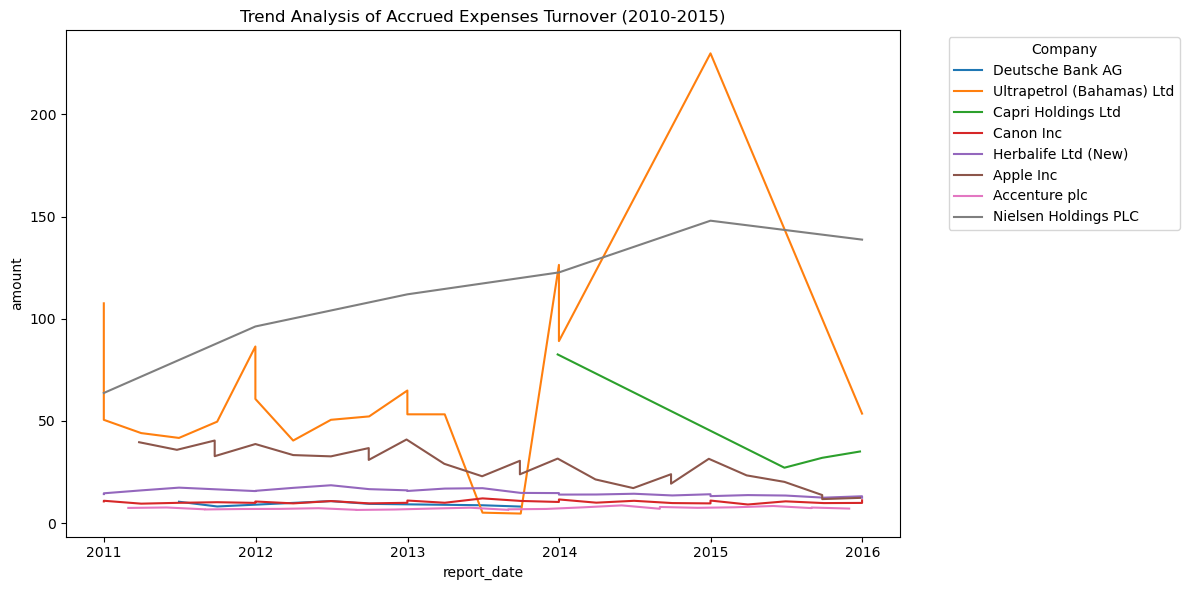

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for company in relevant_data['company_name'].unique():
    company_data = relevant_data[relevant_data['company_name'] == company]
    plt.plot(company_data['report_date'], company_data['amount'],label=company)
    plt.xlabel('report_date')
    plt.ylabel('amount')
    plt.title('Trend Analysis of Accrued Expenses Turnover (2010-2015)')
    plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

plt.show()

Next, we'll perform a Geographical Region Analysis.

# Geographical Region Analysis


In [85]:
# Below we use method chaining to simultaneously group the dataframe by country while finding the mean for the amount column
country_avg = updated_df.groupby('country')['amount'].mean()
country_avg = country_avg.sort_values(ascending=False)
country_avg

country
Bahamas                     66.515369
United States of America    44.377585
GBR                         44.166750
Cayman Islands              15.060796
Japan                       10.376605
Germany                      9.288999
Ireland                      7.264400
Name: amount, dtype: float64

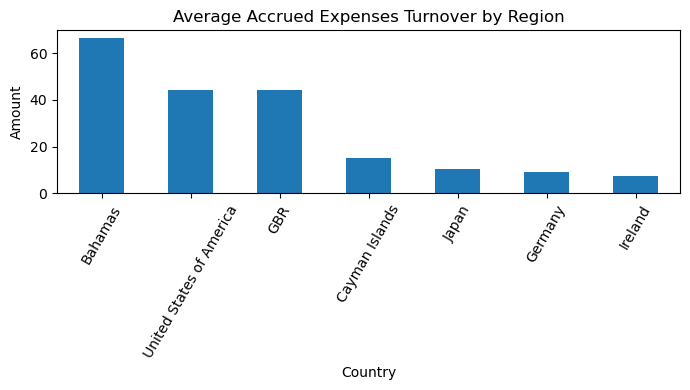

In [51]:
plt.figure(figsize=(7,4))

country_avg.plot(kind='bar',rot=45)
plt.title('Average Accrued Expenses Turnover by Region')
plt.xlabel('Country')
plt.ylabel('Amount')
plt.xticks(rotation=60)
plt.tight_layout()